In [79]:
# ======================================
# Football Betting Model: Championship 2021-2025
# ======================================

import pandas as pd
import numpy as np
import glob
import os
from scipy.stats import poisson
from sklearn.metrics import log_loss, brier_score_loss
import matplotlib.pyplot as plt


In [81]:
# -----------------------------
# 1. Load All CSVs
# -----------------------------
csv_folder = 'Championship21-25'  # folder with Championship_2021.csv ... Championship_2025.csv
essential_cols = [
    'Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG', 'FTR',
    'HTHG', 'HTAG', 'HTR',
    'AvgH', 'AvgD', 'AvgA'
]

all_files = glob.glob(os.path.join(csv_folder, '*.csv'))
data_list = []

for file in all_files:
    df = pd.read_csv(file, usecols=lambda x: x in essential_cols)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['Date', 'HomeTeam', 'AwayTeam', 'FTR'])
    data_list.append(df)

all_data = pd.concat(data_list, ignore_index=True)
all_data = all_data.sort_values('Date')
print(f"Loaded {len(all_data)} matches from {len(all_files)} seasons.")

Loaded 2515 matches from 5 seasons.


In [83]:
# -----------------------------
# 2. Add Time-Decay Weight
# -----------------------------
def add_time_decay(df, alpha=0.002):
    latest_date = df['Date'].max()
    df['days_ago'] = (latest_date - df['Date']).dt.days
    df['weight'] = np.exp(-alpha * df['days_ago'])
    return df

all_data = add_time_decay(all_data)

In [85]:
# -----------------------------
# 3. Train/Test Split (chronological)
# -----------------------------
split_idx = int(len(all_data) * 0.8)
train = all_data.iloc[:split_idx]
test = all_data.iloc[split_idx:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 2012, Test size: 503


In [87]:
# -----------------------------
# 4. Poisson Model Fitting
# -----------------------------
def fit_model(df, iterations=20):
    teams = pd.concat([df['HomeTeam'], df['AwayTeam']]).unique()
    attack = {team: 1.0 for team in teams}
    defence = {team: 1.0 for team in teams}
    home_adv = 1.1

    for _ in range(iterations):
        new_attack = {}
        new_defence = {}
        for team in teams:
            home_games = df[df['HomeTeam'] == team]
            away_games = df[df['AwayTeam'] == team]

            goals_scored = (
                (home_games['FTHG'] * home_games['weight']).sum() +
                (away_games['FTAG'] * away_games['weight']).sum()
            )
            expected = (
                (home_games['weight'] * home_adv).sum() +
                (away_games['weight']).sum()
            )
            new_attack[team] = goals_scored / (expected + 1e-6)

            goals_conceded = (
                (home_games['FTAG'] * home_games['weight']).sum() +
                (away_games['FTHG'] * away_games['weight']).sum()
            )
            new_defence[team] = goals_conceded / (expected + 1e-6)

        attack = new_attack
        defence = new_defence

    return attack, defence, home_adv

attack, defence, home_adv = fit_model(train)



In [89]:
# -----------------------------
# 5. Match Probabilities
# -----------------------------
def match_probs(home, away, attack, defence, home_adv, max_goals=6):
    lam_home = attack[home] * defence[away] * home_adv
    lam_away = attack[away] * defence[home]
    home_win = draw = away_win = 0
    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = poisson.pmf(i, lam_home) * poisson.pmf(j, lam_away)
            if i > j:
                home_win += p
            elif i == j:
                draw += p
            else:
                away_win += p
    return np.array([home_win, draw, away_win])

In [91]:
# -----------------------------
# 6. Implied Market Probabilities
# -----------------------------
def implied_probs(row):
    inv = np.array([1/row['AvgH'], 1/row['AvgD'], 1/row['AvgA']])
    return inv / inv.sum()


In [101]:
# -----------------------------
# 7. Backtest Betting Strategy
# -----------------------------
def backtest(df, attack, defence, home_adv, edge_threshold=0.05):
    bankroll = 0
    bets = 0
    for _, row in df.iterrows():
        home, away = row['HomeTeam'], row['AwayTeam']
        if home not in attack or away not in attack:
            continue
        model_p = match_probs(home, away, attack, defence, home_adv)
        market_p = implied_probs(row)
        model_p = np.clip(model_p, 0.01, 0.98)
        edge = model_p - market_p
        if edge.max() > edge_threshold:
            idx = edge.argmax()
            odds = [row['AvgH'], row['AvgD'], row['AvgA']][idx]
            bets += 1
            if (idx == 0 and row['FTR'] == 'H') or \
               (idx == 1 and row['FTR'] == 'D') or \
               (idx == 2 and row['FTR'] == 'A'):
                bankroll += odds - 1
            else:
                bankroll -= 1
    roi = bankroll / bets if bets > 0 else 0
    return bets, bankroll, roi

bets, profit, roi = backtest(test, attack, defence, home_adv)
print(f"Backtest results: Bets={bets}, Profit={profit:.2f}, ROI={roi:.3f}")


Backtest results: Bets=334, Profit=-27.02, ROI=-0.081


In [55]:
############################
# 7. MAIN PIPELINE
############################

def run():

    # Correct folder path for your Jupyter setup
    df = load_data('Championship21-25/')
    df = add_time_decay(df)

    # Time-based train/test split
    split_date = '2023-01-01'
    train = df[df['Date'] < split_date]
    test = df[df['Date'] >= split_date]

    # Fit Poisson model
    attack, defence, home_adv = fit_model(train)

    # Backtest betting strategy
    bets, profit, roi = backtest(test, attack, defence, home_adv)

    # Results
    print("Results:")
    print(f"Total Bets: {bets}")
    print(f"Profit: {profit:.2f}")
    print(f"ROI: {roi:.3f}")


if __name__ == "__main__":
    run()

Results:
Total Bets: 613
Profit: 44.97
ROI: 0.073


Log-Loss: 1.0730
Brier score (Home): 0.2466
Brier score (Draw): 0.1872
Brier score (Away): 0.2112


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2956: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


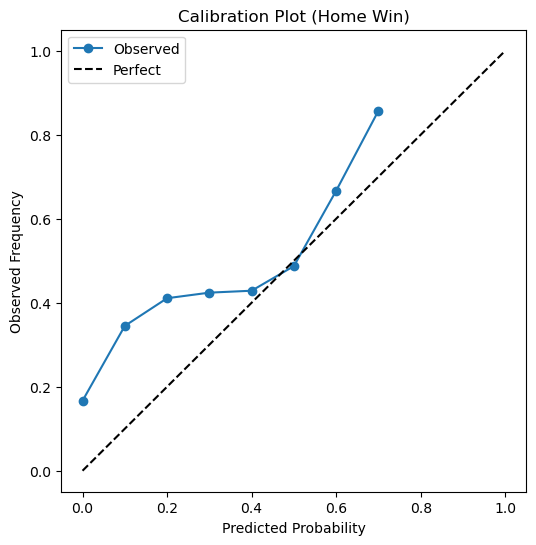

In [95]:
# -----------------------------
# 8. Calibration Metrics
# -----------------------------
def compute_calibration(df, attack, defence, home_adv, max_goals=6):
    y_true = []
    y_prob = []
    for _, row in df.iterrows():
        home, away = row['HomeTeam'], row['AwayTeam']
        if home not in attack or away not in attack:
            continue
        prob = match_probs(home, away, attack, defence, home_adv, max_goals=max_goals)
        y_prob.append(prob)
        outcome = 0 if row['FTR']=='H' else 1 if row['FTR']=='D' else 2
        y_true.append(outcome)
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    if len(y_true)==0:
        print("No valid test samples!")
        return
    ll = log_loss(y_true, y_prob)
    print(f"Log-Loss: {ll:.4f}")
    for i,label in enumerate(['Home','Draw','Away']):
        bs = brier_score_loss((y_true==i).astype(int), y_prob[:,i])
        print(f"Brier score ({label}): {bs:.4f}")
    # Calibration plot (Home win)
    prob_home = y_prob[:,0]
    true_home = (y_true==0).astype(int)
    bins = np.linspace(0,1,11)
    binids = np.digitize(prob_home, bins)-1
    bin_true = [true_home[binids==i].mean() if np.any(binids==i) else np.nan for i in range(len(bins))]
    plt.figure(figsize=(6,6))
    plt.plot(bins, bin_true, marker='o', label='Observed')
    plt.plot([0,1],[0,1],'k--', label='Perfect')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Frequency')
    plt.title('Calibration Plot (Home Win)')
    plt.legend()
    plt.show()

compute_calibration(test, attack, defence, home_adv)